In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sweetviz as sv
from pandas.core.arrays import categorical

In [2]:
train = pd.read_csv("titanic/train.csv", index_col="PassengerId")
test = pd.read_csv("titanic/test.csv", index_col="PassengerId")

In [17]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    str    
 3   Sex       891 non-null    str    
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    str    
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    str    
 10  Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 76.7 KB


In [3]:
report = sv.analyze(train, target_feat="Survived")
report.show_html("report.html")

Feature: Survived (TARGET)                   |▊         | [  8%]   00:00 -> (00:00 left)findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
Feature: Pclass                              |█▋        | [ 17%]   00:00 -> (00:00 left)findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
Feature: Sex                                 |███▎      | [ 33%]   00:00 -> (00:00 left)findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
Feature: Age    

Report report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [10]:
train.columns

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [14]:
numerical_cols = train.select_dtypes(include="number").columns
categorical_cols = train.select_dtypes(include=["str", "category"]).columns

In [8]:
train[train.Age % 1 == 0.5]

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
58,0,3,"Novel, Mr. Mansouer",male,28.5,0,0,2697,7.2292,NaN,C
112,0,3,"Zabour, Miss. Hileni",female,14.5,1,0,2665,14.4542,NaN,C
117,0,3,"Connors, Mr. Patrick",male,70.5,0,0,370369,7.7500,NaN,Q
123,0,2,"Nasser, Mr. Nicholas",male,32.5,1,0,237736,30.0708,NaN,C
124,1,2,"Webber, Miss. Susan",female,32.5,0,0,27267,13.0000,E101,S
149,0,2,"Navratil, Mr. Michel (""Louis M Hoffman"")",male,36.5,0,2,230080,26.0000,F2,S
153,0,3,"Meo, Mr. Alfonzo",male,55.5,0,0,A.5. 11206,8.0500,NaN,S
154,0,3,"van Billiard, Mr. Austin Blyler",male,40.5,0,2,A/5. 851,14.5000,NaN,S
204,0,3,"Youseff, Mr. Gerious",male,45.5,0,0,2628,7.2250,NaN,C


In [16]:
train[numerical_cols].skew().sort_values()

Pclass     -0.630548
Age         0.389108
Survived    0.478523
Parch       2.749117
SibSp       3.695352
Fare        4.787317
dtype: float64

In [18]:
#Fare = 0 impliziert Crew
train[train["Fare"] == 0]

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
180,0,3,"Leonard, Mr. Lionel",male,36.0,0,0,LINE,0.0,NaN,S
264,0,1,"Harrison, Mr. William",male,40.0,0,0,112059,0.0,B94,S
272,1,3,"Tornquist, Mr. William Henry",male,25.0,0,0,LINE,0.0,NaN,S
278,0,2,"Parkes, Mr. Francis ""Frank""",male,NaN,0,0,239853,0.0,NaN,S
303,0,3,"Johnson, Mr. William Cahoone Jr",male,19.0,0,0,LINE,0.0,NaN,S
414,0,2,"Cunningham, Mr. Alfred Fleming",male,NaN,0,0,239853,0.0,NaN,S
467,0,2,"Campbell, Mr. William",male,NaN,0,0,239853,0.0,NaN,S
482,0,2,"Frost, Mr. Anthony Wood ""Archie""",male,NaN,0,0,239854,0.0,NaN,S
598,0,3,"Johnson, Mr. Alfred",male,49.0,0,0,LINE,0.0,NaN,S


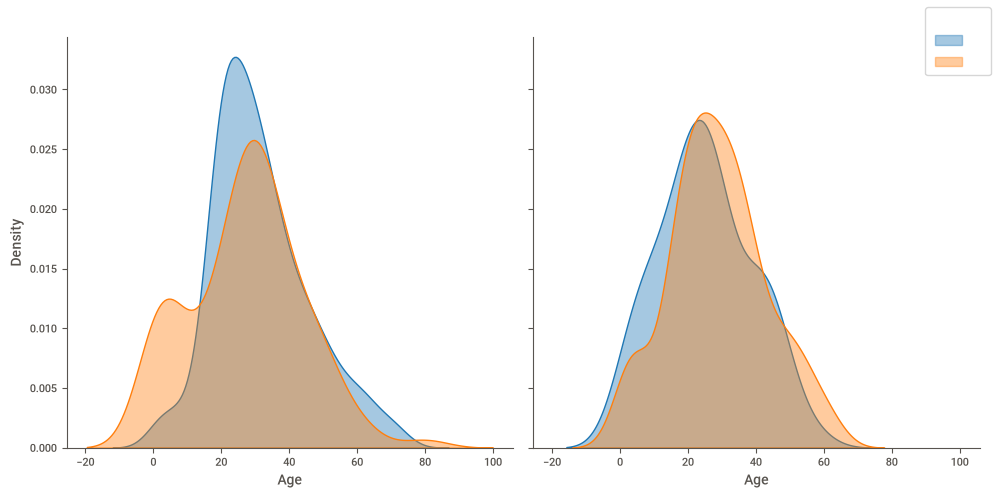

In [41]:
import matplotlib.patches as mpatches

palette = {0: '#1f77b4', 1: '#ff7f0e'}  # Standard seaborn Farben, anpassbar

g = sns.FacetGrid(train, col='Sex', hue='Survived', height=5, aspect=1, palette=palette)
g.map(sns.kdeplot, 'Age', fill=True, alpha=0.4)

handles = [mpatches.Patch(color=palette[0], label='Not Survived', alpha=0.4),
           mpatches.Patch(color=palette[1], label='Survived', alpha=0.4)]
g.fig.legend(handles=handles, title='Survived', loc='upper right', labels=[0, 1])

plt.show()

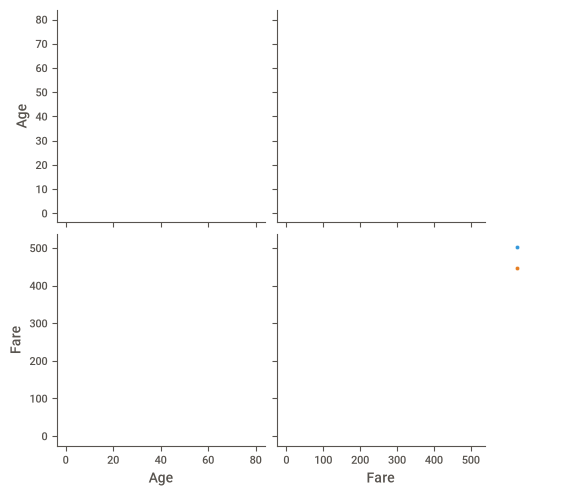

In [37]:
sns.pairplot(
    train,
    vars=['Age', 'Fare'],
    hue='Survived',  # gleiche gemappte Spalte wie oben
    hue_order=['0', '1'],
    palette={'0': '#3498db', '1': '#e67e22'},
    diag_kind='kde'
)
plt.show()

In [42]:
for df in [train, test]:
    df['Deck'] = df['Cabin'].str[0]
    df['Deck'] = df['Deck'].fillna('0')

In [43]:
train["Deck"].value_counts()

Deck
0    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: count, dtype: int64

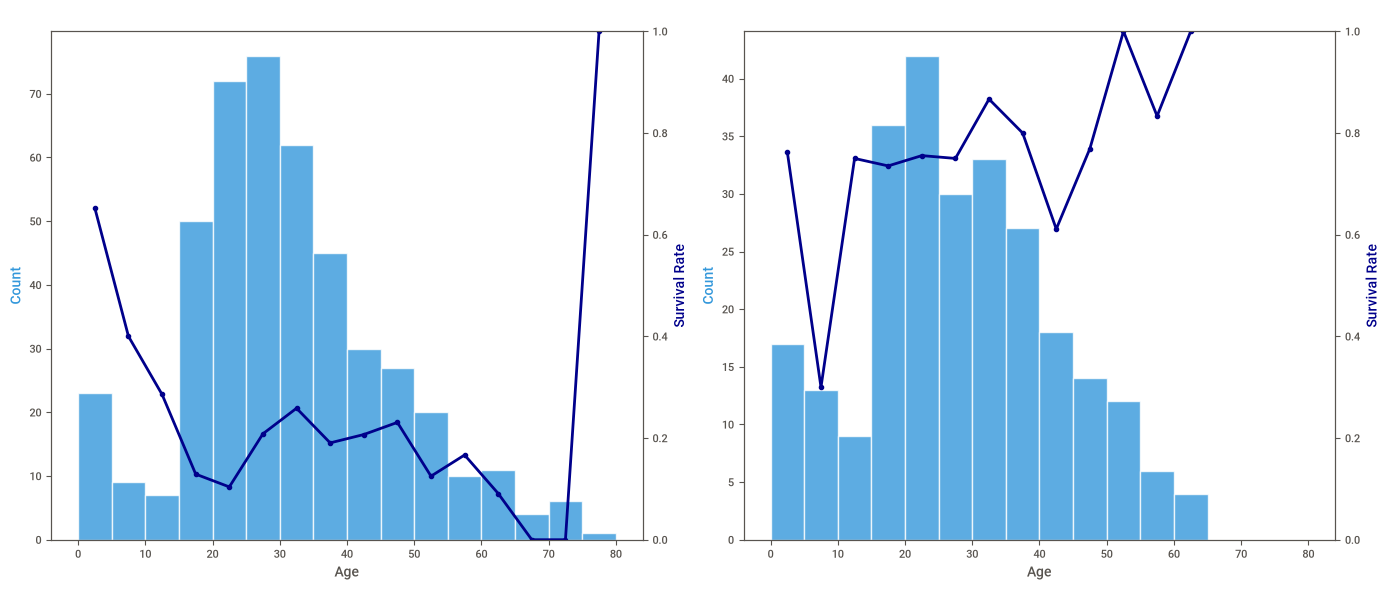

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)
bins = np.arange(0, 85, 5)

for ax, sex in zip(axes, ['male', 'female']):
    subset = train[train['Sex'] == sex]

    # Histogramm (linke Y-Achse)
    ax.hist(subset['Age'].dropna(), bins=bins, color='#3498db',
            edgecolor='white', alpha=0.8)
    ax.set_xlabel('Age')
    ax.set_ylabel('Count', color='#3498db')
    ax.set_title(f'Age-Verteilung: {sex}')

    # Survival-Rate pro Bin (rechte Y-Achse)
    ax2 = ax.twinx()
    subset = subset.copy()
    subset['AgeBin'] = pd.cut(subset['Age'], bins=bins)
    survival_rate = subset.groupby('AgeBin')['Survived'].mean()
    bin_centers = bins[:-1] + 2.5  # Mitte jedes Bins für die Linie

    ax2.plot(bin_centers[:len(survival_rate)], survival_rate.values,
              color='darkblue', marker='o', linewidth=2)
    ax2.set_ylabel('Survival Rate', color='darkblue')
    ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [47]:
train['Ticket'].value_counts().head(20)

Ticket
347082          7
1601            7
CA. 2343        7
3101295         6
CA 2144         6
347088          6
382652          5
S.O.C. 14879    5
349909          4
347077          4
19950           4
W./C. 6608      4
4133            4
LINE            4
113781          4
17421           4
PC 17757        4
113760          4
2666            4
347742          3
Name: count, dtype: int64